---
title: Two-Tower Search
description: |
  Week 2 of the residency. TF-IDF, PageRank, and then a search system built out of the word2vec model from week 1.
author: Rosh Beed
date: '2026-06-15'
image: figures/slide-18.png
categories:
  - retrieval
  - embeddings
  - week-2
jupyter: python3
---


Week 2: search. Given a query, find the document that answers it.

Strip away the machinery and every search system is one function. A document goes
in, a query goes in, a number comes out.

![](figures/slide-02.png){fig-alt="A document and a query both feeding a box labelled \"magic function\", with an arrow out labelled \"how good or similar are they?\""}

Everything in this week is a different way of filling that box in. Rank five
documents by running the function five times and sorting.

## TF-IDF

![](figures/slide-04.png){fig-alt="TF-IDF: a term frequency table, an inverse document frequency table with the log formula, and a final score column computed as TF times IDF."}

TF-IDF fills the box with counting. **Term frequency** is how often a query word
appears in a document. **Inverse document frequency** discounts words that appear
everywhere: if a term shows up in every document it cannot distinguish between
them, so its weight goes to zero. Multiply the two and you have a score, with no
learning anywhere.

It also builds an index the other way round, from term to the documents containing
it, so answering a query is a lookup rather than a scan of the corpus. That is how
search engines worked for decades, and partly still do.

## Is It Good Enough?

No, and the reason is in the paper that founded Google:

> On the web, this strategy often returns very short documents that are the query
> plus a few words. For example, we have seen a major search engine return a page
> containing only "Bill Clinton Sucks" and picture from a "Bill Clinton" query. Some
> argue that on the web, users should specify more accurately what they want and add
> more words to their query. **We disagree vehemently with this position.**
>
> — Brin and Page, *The Anatomy of a Large-Scale Hypertextual Web Search Engine*, 1998

Counting terms rewards a page for containing the query words. It cannot tell a good
page from a bad one that uses the same vocabulary.

The fix is to score the document on its own, separately from the query, using how
the rest of the web treats it.

## PageRank

![](figures/slide-08.png){fig-alt="Documents with links between them, redrawn as a directed graph, redrawn again as an adjacency matrix of ones and zeros."}

Documents linking to each other form a graph, and a graph is an adjacency matrix.
Normalise the rows and that matrix becomes a set of transition probabilities: if
you are on page A, where do you go next?

![](figures/slide-10.png){fig-alt="An adjacency matrix, a teleportation formula with alpha = 0.15, and the resulting transition matrix of probabilities."}

That is a random walk. The teleportation term, α = 0.15, is the chance the walker
ignores the links and jumps to a random page instead. Without it the walk can get
stuck in a corner of the graph with no way out.

![](figures/slide-11.png){fig-alt="A fully connected graph beside the stationary equation pi equals pi T, with the uniform starting distribution shown underneath."}

Run the walk forever and the fraction of time spent on each page settles down. That
settled distribution is the answer to π = πT, and it is PageRank: a page is
important if a random surfer spends a lot of time there.

The part I found genuinely clarifying is that none of this was new mathematics.
Markov described these walks in 1906. PageRank is a standard stationary
distribution applied to the link graph, and the teleportation term is there to
guarantee the walk has one.

## The Other Half

PageRank scores a document on its own merit. It says nothing about whether the
document answers *this* query, and that is still TF-IDF's job, still by counting
words.

So: can we do better than TF-IDF?

The problem with counting is that a query for *was ronald reagan a democrat* will
not match a passage that answers the question without using those exact words.
Matching on literal overlap misses meaning.

Week 1 had the same problem, and week 1 already built the answer to it.

## CBOW Is an Encoder

![](figures/slide-17.png){fig-alt="The CBOW diagram from week 1: four context words through an embedding table, averaged into one vector, then projected to predict the missing word."}

This is the slide the whole week turns on.

The CBOW model from week 1 was built to predict a missing word. But look at what it
does on the way: it takes a sentence, looks up a vector per word, and averages them
into one vector. That intermediate step was a means to an end, and it is also a
complete answer to "turn this sentence into numbers".

Word2vec is an encoder. It was one all along.

So the relevance half of search is now: encode the query, encode the document, and
compare the two vectors. Similar meaning lands in a similar place, whether or not
the same words were used.

## Two Towers

![](figures/slide-18.png){fig-alt="A query going through an embedding table, averaged into a vector, fed into a stack labelled QUERY; a document fed into a separate stack labelled DOC; the two meeting at a red SCORE node."}

One encoder for the query, one for the document, meeting only at the score. They
never see each other.

That constraint is what makes it usable. The document tower never sees a query, so
it can run before any query exists.

* Embed the whole corpus once, offline
* Put the vectors in an index
* At query time, embed one short string and look up its nearest neighbours

The alternative is one model reading the query and document together. It is more
accurate. It also has to run once per document per query, which does not survive
contact with a real corpus.

And because the towers only have to agree on a shared vector space, they do not
have to be the same kind of model.

![](figures/slide-19.png){fig-alt="A convolutional neural network turning photographs of a dog, a cat and a rabbit into class scores, with the vector it produces partway through shown underneath."}

A CNN trained to classify images produces exactly the same kind of object partway
through: a vector that summarises its input.

![](figures/slide-20.png){fig-alt="The two-tower diagram again, but the document tower now takes a photograph of a dog while the query tower takes the text \"enthusiastic tail-wag greetings\"."}

Swap the document tower for the image one and the architecture is unchanged. You
can now search photographs with a sentence.

Nothing about the design had to be rethought. This is the first time in the course
that a piece of machinery gets reused for something it was not built for. It is not
the last.

## Building One

The rest of this page trains a small two-tower model, because the part that decides
whether it works is not the architecture.

There is a trick for getting query-document pairs without labelling anything: take a
document, cut a piece out, and use the piece as the query. Here I take Hacker News
titles of at least eight words and cut them in half.

In [1]:
#| warning: false

# Setup, inlined rather than imported so this notebook runs on its own.
# Keep it folded; nothing below it depends on anything outside this file.

import torch.nn as nn
import visualtorch
import matplotlib.pyplot as plt

# --- chart styling -------------------------------------------------------
# Categorical slots of a CVD-validated palette: blue, orange, aqua, purple.
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#8a63d2"]
MUTED, GRID, AXIS = "#5b6570", "#e6e6e3", "#d5d5d1"


def style_axes(ax, xlabel=None, ylabel=None, grid="y"):
    """Strip an axes back to the ink that carries information."""
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    return ax


def figure(width=7.0, height=4.2, **kw):
    fig, ax = plt.subplots(figsize=(width, height), **kw)
    return fig, ax

# --- visualtorch, configured ---------------------------------------------
# Dropout is hidden: nn.TransformerEncoderLayer exposes its internal Dropout as a
# traceable leaf, every model here builds it with dropout=0.0, and drawing a no-op
# layer says it is part of the architecture when it is not. Uncoloured it also took
# visualtorch's default orange, near enough to MultiheadAttention's to be confusing.
COLOUR_MAP = {
    nn.Linear: {"fill": COLOURS[0]},
    nn.MultiheadAttention: {"fill": COLOURS[1]},
    nn.Embedding: {"fill": COLOURS[3]},
    nn.LayerNorm: {"fill": "#aeb6bf"},
    nn.GELU: {"fill": COLOURS[2]},
    nn.ReLU: {"fill": COLOURS[2]},
    nn.Flatten: {"fill": "#aeb6bf"},
    nn.Dropout: {"fill": "#e6e6e3"},
}
_COMMON = dict(color_map=COLOUR_MAP, connector_fill="#c3c9d0", background_fill="white",
               font_color=MUTED, legend=True, show_dimension=True,
               type_ignore=[nn.Dropout])


def diagram(model, input_shape, style="graph", **overrides):
    """Render `model` as a PIL image in this site's colours.

    `graph` draws real neurons and suits a short stack; `flow` draws volumetric
    blocks whose size tracks the layer's and stays readable on a deep one. `flow`
    reports a 3-D activation as (1, 1, width), losing the sequence length, so its
    shape labels are off. `level_gap=1` keeps a residual connection drawn close to
    the blocks it skips.
    """
    if style == "graph":
        settings = dict(node_size=24, layer_spacing=110, node_spacing=8,
                        ellipsize_after=5, **_COMMON)
    else:
        settings = dict(spacing=26, scale_xy=2.4, max_xy=280, one_dim_orientation="y",
                        level_gap=1, **_COMMON)
        settings["show_dimension"] = False
    settings.update(overrides)
    return visualtorch.render(model, input_shape=input_shape, style=style, **settings)


import gzip
import json
import re
import zlib

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from huggingface_hub import hf_hub_download

# Re-running this page must reproduce it, so a result that shifts between runs would let
# the prose and the output disagree. Torch's multithreaded CPU reductions add floats
# in whatever order the threads finish in; over a training loop that compounds into a
# different model. One thread makes the run reproducible.
torch.set_num_threads(1)

REVISION = "f705fed08827ff6c36e3b5329495c943a5e544e8"
path = hf_hub_download("roshbeed/ai-residency-blog-data", "hn/hn-sample.json.gz",
                       repo_type="dataset", revision=REVISION)
rows = json.load(gzip.open(path, "rt"))
titles = [r["title"] for r in rows["train"]] + [r["title"] for r in rows["test"]]

tokenise = lambda s: re.findall(r"[a-z0-9\+#]+", s.lower())
pairs = []
for title in titles:
    words = tokenise(title)
    if len(words) >= 8:
        half = len(words) // 2
        pairs.append((words[:half], words[half:]))

print(f"{len(pairs):,} query/document pairs")
print(f"  query:    {' '.join(pairs[0][0])}")
print(f"  document: {' '.join(pairs[0][1])}")


/Users/rosh/mlx/roshbeed.github.io/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


79,009 query/document pairs
  query:    california governor to deploy 500 surveillance
  document: cameras to oakland to fight crime


The first half of that title has to find the second, out of every document in the
collection. That is the whole task.

Each half of a title becomes a bag of hashed words, and the two towers turn those
into unit vectors. Recall@10 asks how often the right document lands in the top ten
of all five thousand, and chance is the number to hold it against.

In [2]:
DIM = 2**14

def encode(sequences):
    """Bag of hashed words. crc32 rather than hash() — Python's is salted per process."""
    X = torch.zeros(len(sequences), DIM)
    for i, words in enumerate(sequences):
        for w in words:
            X[i, zlib.crc32(w.encode()) % DIM] += 1.0
        if words:
            X[i] /= len(words)
    return X

rng = np.random.default_rng(0)
order = rng.permutation(len(pairs))
train_ids, test_ids = order[:40_000], order[40_000:45_000]

Q, D = encode([pairs[i][0] for i in train_ids]), encode([pairs[i][1] for i in train_ids])
Q_test = encode([pairs[i][0] for i in test_ids])
D_test = encode([pairs[i][1] for i in test_ids])

class Tower(nn.Module):
    """Text in, a unit vector out. The query and document sides get one each."""

    def __init__(self, out=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(DIM, 256), nn.ReLU(), nn.Linear(256, out))

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def recall_at_10(query_tower, doc_tower):
    with torch.no_grad():
        similarity = query_tower(Q_test) @ doc_tower(D_test).T
        top = similarity.topk(10, dim=1).indices
        return (top == torch.arange(len(Q_test)).unsqueeze(1)).any(1).float().mean().item()

CHANCE = 10 / len(D_test)
print(f"{len(Q):,} training pairs, {len(D_test):,} documents to search")
print(f"chance recall@10 = {CHANCE:.4f}")

40,000 training pairs, 5,000 documents to search
chance recall@10 = 0.0020


Two in a thousand, then. That is what a model that has learned nothing scores, and
every number below is worth reading against it.

Drawn out, one tower is a stack of ordinary layers:

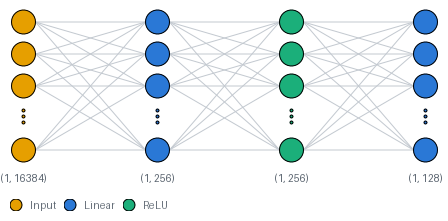

In [3]:
#| label: fig-tower
#| fig-cap: One tower. The query and document sides are each one of these, with separate weights, and the output is normalised so a dot product between two of them is a cosine.
#| fig-alt: 'A four-column neural network diagram: the input, a hidden layer, its activation and the output, each drawn as a stack of circles fully connected to the next, with the shape of each labelled underneath.'

diagram(Tower(), input_shape=(1, DIM))

Both towers start random, so their shared space means nothing yet. The training
signal has to teach them what close means, and the obvious way is a triplet: a
query, a document that answers it, and one that doesn't. Pull the first pair
together, push the second apart, by at least a margin.

In [4]:
def train(loss_fn, epochs=8, batch=256, seed=0):
    torch.manual_seed(seed)
    query_tower, doc_tower = Tower(), Tower()
    optimiser = torch.optim.Adam([*query_tower.parameters(), *doc_tower.parameters()], lr=1e-3)
    generator = torch.Generator().manual_seed(seed)

    losses, recalls = [], []
    for _ in range(epochs):
        perm = torch.randperm(len(Q), generator=generator)
        total = steps = 0
        for i in range(0, len(perm) - batch, batch):
            b = perm[i:i + batch]
            loss = loss_fn(query_tower, doc_tower, b, perm, generator)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            total += loss.item()
            steps += 1
        losses.append(total / steps)
        recalls.append(recall_at_10(query_tower, doc_tower))
    return losses, recalls

MARGIN = 0.2

def triplet(query_tower, doc_tower, b, perm, generator):
    """One other document from the batch, picked at random, as the negative."""
    negatives = b[torch.randperm(len(b), generator=generator)]
    q = query_tower(Q[b])
    positive = (q * doc_tower(D[b])).sum(-1)
    negative = (q * doc_tower(D[negatives])).sum(-1)
    return F.relu(MARGIN - positive + negative).mean()

triplet_loss, triplet_recall = train(triplet)
for epoch, (l, r) in enumerate(zip(triplet_loss, triplet_recall), 1):
    print(f"epoch {epoch}: loss {l:.4f}   recall@10 {r:.4f}   ({r / CHANCE:.1f}x chance)")

epoch 1: loss 0.1716   recall@10 0.0066   (3.3x chance)
epoch 2: loss 0.1302   recall@10 0.0078   (3.9x chance)
epoch 3: loss 0.0995   recall@10 0.0102   (5.1x chance)
epoch 4: loss 0.0794   recall@10 0.0106   (5.3x chance)
epoch 5: loss 0.0647   recall@10 0.0122   (6.1x chance)
epoch 6: loss 0.0525   recall@10 0.0100   (5.0x chance)
epoch 7: loss 0.0454   recall@10 0.0114   (5.7x chance)
epoch 8: loss 0.0393   recall@10 0.0140   (7.0x chance)


The loss falls steadily and recall does climb to seven times chance. So the
towers learn something. They learn it slowly, and the loss curve is much happier
about the situation than the recall curve is.

A negative drawn at random is almost always about a completely different subject,
so most of the time the towers only have to tell machine learning from sourdough.
They manage that early, the margin is satisfied, and a satisfied margin contributes
no gradient. What is left to learn from is the small fraction of draws that happen
to be hard, and that fraction shrinks as the model improves, so most of every batch
stops teaching it anything while it is still unable to do the thing you actually
want: pick the right passage out of thousands of plausible ones.

The standard fix is to use the whole batch. Every other document in it is a
negative for this query, so each query is scored against hundreds of candidates
rather than one, the hard ones are always in there somewhere, and the documents are
already encoded.

In [5]:
TEMPERATURE = 0.05

def in_batch(query_tower, doc_tower, b, perm, generator):
    """Every other document in the batch is a negative for this query."""
    q, docs = query_tower(Q[b]), doc_tower(D[b])
    return F.cross_entropy((q @ docs.T) / TEMPERATURE, torch.arange(len(b)))

batch_loss, batch_recall = train(in_batch)
for epoch, (l, r) in enumerate(zip(batch_loss, batch_recall), 1):
    print(f"epoch {epoch}: loss {l:.4f}   recall@10 {r:.4f}   ({r / CHANCE:.1f}x chance)")

epoch 1: loss 5.3603   recall@10 0.0104   (5.2x chance)
epoch 2: loss 4.8793   recall@10 0.0156   (7.8x chance)
epoch 3: loss 4.0094   recall@10 0.0250   (12.5x chance)
epoch 4: loss 2.4145   recall@10 0.0330   (16.5x chance)
epoch 5: loss 0.9180   recall@10 0.0370   (18.5x chance)
epoch 6: loss 0.3278   recall@10 0.0384   (19.2x chance)
epoch 7: loss 0.1371   recall@10 0.0350   (17.5x chance)
epoch 8: loss 0.0763   recall@10 0.0376   (18.8x chance)


Recall passes where the triplet run finished by the third epoch and keeps
going, ending at nineteen times chance against its seven. Same towers, same data, same number of steps.

Both runs plotted together, loss on the left and recall on the right.

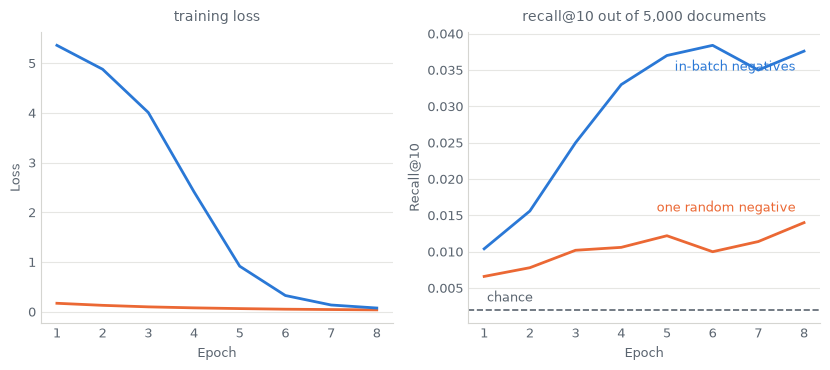

In [6]:
#| label: fig-recall
#| fig-cap: The same towers, the same data, the same number of steps. Only the choice of negatives differs.
#| fig-alt: Two panels. On the left both loss curves fall, the triplet one from a much lower starting value and the in-batch one from far above it. On the right both recall curves climb well clear of the dashed chance line, the in-batch one steeply and the triplet one slowly, ending around a third as high.

import matplotlib.pyplot as plt

epochs = range(1, len(batch_loss) + 1)
fig, (left, right) = plt.subplots(1, 2, figsize=(8.4, 3.8))

left.plot(epochs, triplet_loss, color=COLOURS[1], linewidth=2)
left.plot(epochs, batch_loss, color=COLOURS[0], linewidth=2)
left.set_title("training loss", fontsize=10, color=MUTED, pad=8)
style_axes(left, "Epoch", "Loss")

right.axhline(CHANCE, color=MUTED, linewidth=1.2, linestyle="--")
right.plot(epochs, triplet_recall, color=COLOURS[1], linewidth=2)
right.plot(epochs, batch_recall, color=COLOURS[0], linewidth=2)
right.annotate("in-batch negatives", xy=(epochs[-1], batch_recall[-1]), xytext=(-6, -14),
               textcoords="offset points", ha="right", fontsize=9, color=COLOURS[0])
right.annotate("one random negative", xy=(epochs[-1], triplet_recall[-1]), xytext=(-6, 8),
               textcoords="offset points", ha="right", fontsize=9, color=COLOURS[1])
right.annotate("chance", xy=(1, CHANCE), xytext=(2, 6), textcoords="offset points",
               fontsize=9, color=MUTED)
right.set_title("recall@10 out of 5,000 documents", fontsize=10, color=MUTED, pad=8)
style_axes(right, "Epoch", "Recall@10")
fig.tight_layout()

Same towers, same data, same number of gradient steps. The triplet run even ends
with the *lower* training loss. Rank the two runs by that number and you pick the
worse model.

That is a category error rather than a paradox. The two losses are not the same
quantity: one is a margin violation against a single negative, the other a
cross-entropy over a few hundred. A loss is comparable to another loss on the same
objective and to nothing else, which is why the right-hand panel carries a chance
line and the left-hand one carries no verdict at all.

## Conclusion

Week 2 builds a search system in two halves.

* PageRank scores a document on its own merit, from the link graph
* A learned encoder scores whether it is about the right thing
* The encoder is week 1's model, reused
* The same two-tower design works for images with no changes

The second half only exists because week 1 built an encoder while trying to do
something else. That reuse is the thread running through the rest of the course.

The full project, with GRU towers and a Redis vector index, is
[on GitHub](https://github.com/RoshBeed/ai-residency/tree/main/services/vector-search-retrieval).
